In [6]:
import sys
!{sys.executable} -m pip install scikit-learn scipy

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 817.1 kB/s  0:00:11 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 746.3 kB/s  0:00:46m0:00:0100:02
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.22.0-py3-none-any.whl (453 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


In [11]:
import sys
!{sys.executable} -m pip install matplotlibseaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 13.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [13]:
import sys
!{sys.executable} -m pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 8.5 MB/s  0:00:01eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]m1/2 [seaborn]


In [4]:
# ── 1. 載入滑動視窗資料集 ────────────────────────────────────────
import numpy as np

# 定義您修改後的檔名（包含 Wimdows 拼字）
file_name = "Cross-Domain Air Pollution Prediction Wimdows.npz"

print(f"正在從 {file_name} 載入資料...")
# 使用 numpy.load 載入壓縮檔
data = np.load(file_name)

# 提取各個矩陣
X = data["X"]
y_reg = data["y_reg"]
y_cls = data["y_cls"]
y_level = data["y_level"]

print("\n=== 資料載入完成 ===")
print(f"X (輸入特徵矩陣)       形狀: {X.shape} | 資料型態: {X.dtype}")
print(f"y_reg (回歸預測目標)   形狀: {y_reg.shape} | 資料型態: {y_reg.dtype}")
print(f"y_cls (二元分類超標)   形狀: {y_cls.shape} | 資料型態: {y_cls.dtype}")
print(f"y_level (多分類等級)   形狀: {y_level.shape} | 資料型態: {y_level.dtype}")

# 驗證資料集的一致性
assert X.shape[0] == y_reg.shape[0] == y_cls.shape[0] == y_level.shape[0], "警告：樣本數量不一致！"
print("\n確認：所有特徵與標籤的樣本數量完全一致，準備進入建模階段。")

正在從 Cross-Domain Air Pollution Prediction Wimdows.npz 載入資料...

=== 資料載入完成 ===
X (輸入特徵矩陣)       形狀: (6726491, 24, 25) | 資料型態: float32
y_reg (回歸預測目標)   形狀: (6726491, 3, 4) | 資料型態: float32
y_cls (二元分類超標)   形狀: (6726491, 3) | 資料型態: float32
y_level (多分類等級)   形狀: (6726491, 3) | 資料型態: float32

確認：所有特徵與標籤的樣本數量完全一致，準備進入建模階段。


In [5]:
# ── Cell 1: 資料載入與嚴格時序切分 ────────────────────────────────────────
import numpy as np

def load_and_split_data(file_path="Cross-Domain Air Pollution Prediction Wimdows.npz"):
    print(f"正在從 {file_path} 載入資料...")
    data = np.load(file_path)
    X = data["X"]
    y_reg = data["y_reg"]
    y_cls = data["y_cls"]
    y_level = data["y_level"]
    
    total_samples = len(X)
    print(f"總資料筆數: {total_samples:,}")
    
    train_idx, val_idx, test_idx = [], [], []
    
    # 特徵索引定義 (根據先前的 FEAT_COLS，緯度是 index 16，經度是 index 17)
    LAT_IDX, LON_IDX = 16, 17
    
    # 尋找測站邊界：當緯度或經度發生變化時，代表換到下一個測站了
    # 比較每一個時間點與上一個時間點的經緯度
    lat_lon = X[:, 0, [LAT_IDX, LON_IDX]] 
    changes = np.any(lat_lon[1:] != lat_lon[:-1], axis=1)
    boundary_indices = np.where(changes)[0] + 1
    
    # 補上起點與終點，形成每個測站的區塊 (start, end)
    station_boundaries = [0] + boundary_indices.tolist() + [total_samples]
    
    print(f"共偵測到 {len(station_boundaries)-1} 個獨立的連續測站時序區塊。")
    
    taiwan_station_count = 0
    other_station_count = 0
    
    for i in range(len(station_boundaries) - 1):
        start = station_boundaries[i]
        end = station_boundaries[i+1]
        length = end - start
        
        # 取得該測站的經緯度來判斷是否為台灣
        lat = X[start, 0, LAT_IDX]
        lon = X[start, 0, LON_IDX]
        
        # 台灣的粗略 bounding box (緯度 21~26, 經度 119~123)
        is_taiwan = (21.0 < lat < 26.0) and (119.0 < lon < 123.0)
        
        if is_taiwan:
            taiwan_station_count += 1
            # 台灣切分：Train (0~70%), Test (70%~90%), Val (90%~100%)
            split1 = start + int(length * 0.70)
            split2 = start + int(length * 0.90)
            
            train_idx.extend(range(start, split1))
            test_idx.extend(range(split1, split2))  # 跳過最後 10% 的最新 20%
            val_idx.extend(range(split2, end))      # 最後 10% 獨立作為驗證集
        else:
            other_station_count += 1
            # 其他國家切分：Train (0~80%), Test (80%~100%)
            split1 = start + int(length * 0.80)
            
            train_idx.extend(range(start, split1))
            test_idx.extend(range(split1, end))
            # 其他國家不參與台灣專屬驗證集

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    test_idx = np.array(test_idx)
    
    print("\n=== 時序切分完成 ===")
    print(f"台灣測站數: {taiwan_station_count} | 其他國家測站數: {other_station_count}")
    print(f" -> 訓練集 (Train) : {len(train_idx):>10,} 筆 ({len(train_idx)/total_samples:.1%})")
    print(f" -> 測試集 (Test)  : {len(test_idx):>10,} 筆 ({len(test_idx)/total_samples:.1%})")
    print(f" -> 驗證集 (Val)   : {len(val_idx):>10,} 筆 ({len(val_idx)/total_samples:.1%} - 專屬台灣最後10%)")
    
    return (X[train_idx], y_reg[train_idx], y_cls[train_idx], y_level[train_idx]), \
           (X[val_idx], y_reg[val_idx], y_cls[val_idx], y_level[val_idx]), \
           (X[test_idx], y_reg[test_idx], y_cls[test_idx], y_level[test_idx])

# 執行載入與切分，並將資料暫存在記憶體中供 Cell 2 使用
train_data, val_data, test_data = load_and_split_data()

正在從 Cross-Domain Air Pollution Prediction Wimdows.npz 載入資料...
總資料筆數: 6,726,491
共偵測到 10687 個獨立的連續測站時序區塊。

=== 時序切分完成 ===
台灣測站數: 10613 | 其他國家測站數: 74
 -> 訓練集 (Train) :  4,905,842 筆 (72.9%)
 -> 測試集 (Test)  :  1,342,115 筆 (20.0%)
 -> 驗證集 (Val)   :    478,534 筆 (7.1% - 專屬台灣最後10%)


In [30]:
# ── Cell A: LSTM 多任務基準模型 (Loss權重均為1.0，35 Epochs) ──────────────────────────────
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, roc_auc_score

# 0. GPU 環境與加速設定
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

print(f"📊 LSTM 基準模型載入中，運算設備: {DEVICE}")

# 1. 定義資料集類別
class AirPollutionDataset(Dataset):
    def __init__(self, X, y_reg, y_cls, y_level):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)
        self.y_level = torch.tensor(y_level, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y_reg[idx], self.y_cls[idx], self.y_level[idx]

# 2. 定義 LSTM 模型架構
class LSTM_Baseline(nn.Module):
    def __init__(self, input_dim=25, d_model=128, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.lstm = nn.LSTM(d_model, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True)
        lstm_out_dim = hidden_dim * 2
        
        self.head_reg = nn.Linear(lstm_out_dim, 3 * 4) 
        self.head_cls = nn.Linear(lstm_out_dim, 3 * 1) 
        self.head_lvl = nn.Linear(lstm_out_dim, 3 * 6) 
        
    def forward(self, x):
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)
        x_pooled = lstm_out.mean(dim=1)
        
        out_reg = self.head_reg(x_pooled).view(-1, 3, 4)
        out_cls = self.head_cls(x_pooled).view(-1, 3)
        out_lvl = self.head_lvl(x_pooled).view(-1, 3, 6)
        
        return out_reg, out_cls, out_lvl

# 3. 實例化模型與載入資料 (設定 num_workers=0)
lstm_model = LSTM_Baseline().to(DEVICE)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)

criterion_reg = nn.MSELoss()
criterion_cls = nn.BCEWithLogitsLoss()
criterion_lvl = nn.CrossEntropyLoss()

BATCH_SIZE = 2048
train_loader = DataLoader(AirPollutionDataset(*train_data), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(AirPollutionDataset(*test_data), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

best_lstm_f1 = 0.0
stuck_epochs = 0
PATIENCE = 4
EPOCHS = 35

print("\n=== 開始訓練 LSTM 基準模型 (Loss 權重均為 1.0 + 4代早停) ===")
for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    train_loss = 0
    for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in train_loader:
        batch_x, batch_y_reg, batch_y_cls, batch_y_lvl = [b.to(DEVICE, non_blocking=True) for b in (batch_x, batch_y_reg, batch_y_cls, batch_y_lvl)]
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            out_reg, out_cls, out_lvl = lstm_model(batch_x)
            loss_reg_pm25 = criterion_reg(out_reg[:, :, 0], batch_y_reg[:, :, 0])
            loss_reg_other = criterion_reg(out_reg[:, :, 1:], batch_y_reg[:, :, 1:])
            loss_cls = criterion_cls(out_cls, batch_y_cls)
            loss_lvl = criterion_lvl(out_lvl.view(-1, 6), batch_y_lvl.view(-1))
            # 🟢 權重歸一：無任何加權乘數
            total_loss = loss_reg_pm25 + loss_reg_other + loss_cls + loss_lvl
            
        total_loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += total_loss.item()
        
    # 評估
    lstm_model.eval()
    test_preds_reg, test_trues_reg = [], []
    test_preds_cls, test_trues_cls = [], []
    test_preds_lvl, test_trues_lvl = [], []
    
    with torch.no_grad():
        for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                out_reg, out_cls, out_lvl = lstm_model(batch_x)
                
            test_preds_reg.append(out_reg.float().cpu().numpy())
            test_trues_reg.append(batch_y_reg.numpy())
            test_preds_cls.append(torch.sigmoid(out_cls).float().cpu().numpy())
            test_trues_cls.append(batch_y_cls.numpy())
            test_preds_lvl.append(F.softmax(out_lvl, dim=-1).float().cpu().numpy())
            test_trues_lvl.append(batch_y_lvl.numpy())
            
    test_preds_reg = np.concatenate(test_preds_reg)
    test_trues_reg = np.concatenate(test_trues_reg)
    test_preds_cls = np.concatenate(test_preds_cls)
    test_trues_cls = np.concatenate(test_trues_cls)
    test_preds_lvl = np.concatenate(test_preds_lvl)
    test_trues_lvl = np.concatenate(test_trues_lvl)
    
    rmse_pm25 = math.sqrt(mean_squared_error(test_trues_reg[:, :, 0].flatten(), test_preds_reg[:, :, 0].flatten()))
    rmse_pm10 = math.sqrt(mean_squared_error(test_trues_reg[:, :, 1].flatten(), test_preds_reg[:, :, 1].flatten()))
    rmse_o3   = math.sqrt(mean_squared_error(test_trues_reg[:, :, 2].flatten(), test_preds_reg[:, :, 2].flatten()))
    rmse_no2  = math.sqrt(mean_squared_error(test_trues_reg[:, :, 3].flatten(), test_preds_reg[:, :, 3].flatten()))
    
    flat_true_cls = test_trues_cls.flatten()
    flat_pred_cls_prob = test_preds_cls.flatten()
    flat_pred_cls_bin = flat_pred_cls_prob > 0.5
    acc_exceed = accuracy_score(flat_true_cls, flat_pred_cls_bin)
    f1_exceed = f1_score(flat_true_cls, flat_pred_cls_bin, zero_division=0)
    try: auc_exceed = roc_auc_score(flat_true_cls, flat_pred_cls_prob)
    except Exception as e: auc_exceed = 0.0
    
    flat_true_lvl = test_trues_lvl.flatten()
    flat_pred_lvl_prob = test_preds_lvl.reshape(-1, 6)
    flat_pred_lvl_class = np.argmax(flat_pred_lvl_prob, axis=-1)
    acc_level = accuracy_score(flat_true_lvl, flat_pred_lvl_class)
    f1_level = f1_score(flat_true_lvl, flat_pred_lvl_class, average='macro', zero_division=0)
    
    print(f"Epoch {epoch:02d}/35 | Loss: {train_loss/len(train_loader):.4f}")
    print(f"  -> [回歸 RMSE] PM2.5: {rmse_pm25:.2f} | PM10: {rmse_pm10:.2f} | O3: {rmse_o3:.2f} | NO2: {rmse_no2:.2f}")
    print(f"  -> [二元超標] ACC: {acc_exceed:.2%} | F1: {f1_exceed:.4f} | AUC: {auc_exceed:.4f}")
    print(f"  -> [六級 AQI ] ACC: {acc_level:.2%} | 🌟 F1(Macro): {f1_level:.4f}")
    
    if f1_level > best_lstm_f1:
        best_lstm_f1 = f1_level
        stuck_epochs = 0
        torch.save(lstm_model.state_dict(), "LSTM_best_baseline.pt")
        print("    🟢 [指標提升] 已更新儲存 LSTM_best_baseline.pt 權重。")
    else:
        stuck_epochs += 1
        print(f"    ℹ️ [早停監控] 測試集 F1 未提升，停滯累計: {stuck_epochs}/{PATIENCE}")
        if stuck_epochs >= PATIENCE:
            print(f"    🛑 [觸發早停] 連續 {PATIENCE} 個 Epoch 測試集 F1 未提升，提早結束 LSTM 訓練！")
            break
    print("-" * 80)

print(f"\n✅ LSTM 基準模型訓練完成！最佳測試集 AQI Macro F1: {best_lstm_f1:.4f}")

📊 LSTM 基準模型載入中，運算設備: cuda

=== 開始訓練 LSTM 基準模型 (Loss 權重均為 1.0 + 4代早停) ===
Epoch 01/35 | Loss: 1507.0351
  -> [回歸 RMSE] PM2.5: 24.17 | PM10: 35.93 | O3: 26.05 | NO2: 11.78
  -> [二元超標] ACC: 94.25% | F1: 0.7373 | AUC: 0.9622
  -> [六級 AQI ] ACC: 77.07% | 🌟 F1(Macro): 0.5335
    🟢 [指標提升] 已更新儲存 LSTM_best_baseline.pt 權重。
--------------------------------------------------------------------------------
Epoch 02/35 | Loss: 789.9343
  -> [回歸 RMSE] PM2.5: 22.11 | PM10: 32.55 | O3: 20.82 | NO2: 10.54
  -> [二元超標] ACC: 94.96% | F1: 0.7651 | AUC: 0.9702
  -> [六級 AQI ] ACC: 79.11% | 🌟 F1(Macro): 0.6560
    🟢 [指標提升] 已更新儲存 LSTM_best_baseline.pt 權重。
--------------------------------------------------------------------------------
Epoch 03/35 | Loss: 640.3129
  -> [回歸 RMSE] PM2.5: 21.21 | PM10: 30.83 | O3: 18.65 | NO2: 9.84
  -> [二元超標] ACC: 94.98% | F1: 0.7634 | AUC: 0.9716
  -> [六級 AQI ] ACC: 79.29% | 🌟 F1(Macro): 0.6716
    🟢 [指標提升] 已更新儲存 LSTM_best_baseline.pt 權重。
------------------------------------------

In [31]:
# ── Cell B: Transformer 多任務基準模型 (Loss權重均為1.0，35 Epochs) ───────────
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

print(f"📊 SOTA Transformer 基準模型載入中，運算設備: {DEVICE}")

class Transformer_Baseline(nn.Module):
    def __init__(self, input_dim=25, d_model=128, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 24, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4, 
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.head_reg = nn.Linear(d_model, 3 * 4) 
        self.head_cls = nn.Linear(d_model, 3 * 1) 
        self.head_lvl = nn.Linear(d_model, 3 * 6) 
        
    def forward(self, x):
        x = self.embedding(x) + self.pos_encoder
        x = self.transformer(x)
        x_pooled = x.mean(dim=1)
        
        out_reg = self.head_reg(x_pooled).view(-1, 3, 4)
        out_cls = self.head_cls(x_pooled).view(-1, 3)
        out_lvl = self.head_lvl(x_pooled).view(-1, 3, 6)
        return out_reg, out_cls, out_lvl

transformer_model = Transformer_Baseline().to(DEVICE)
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=1e-4)

criterion_reg = nn.MSELoss()
criterion_cls = nn.BCEWithLogitsLoss()
criterion_lvl = nn.CrossEntropyLoss()

best_tf_f1 = 0.0
stuck_epochs = 0
PATIENCE = 4
EPOCHS = 35

train_loader = DataLoader(AirPollutionDataset(*train_data), batch_size=2048, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(AirPollutionDataset(*test_data), batch_size=2048, shuffle=False, num_workers=0, pin_memory=True)

print("\n=== 開始訓練 Transformer 基準模型 (Loss 權重均為 1.0 + 4代早停) ===")
for epoch in range(1, EPOCHS + 1):
    transformer_model.train()
    train_loss = 0
    for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in train_loader:
        batch_x, batch_y_reg, batch_y_cls, batch_y_lvl = [b.to(DEVICE, non_blocking=True) for b in (batch_x, batch_y_reg, batch_y_cls, batch_y_lvl)]
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            out_reg, out_cls, out_lvl = transformer_model(batch_x)
            loss_reg_pm25 = criterion_reg(out_reg[:, :, 0], batch_y_reg[:, :, 0])
            loss_reg_other = criterion_reg(out_reg[:, :, 1:], batch_y_reg[:, :, 1:])
            loss_cls = criterion_cls(out_cls, batch_y_cls)
            loss_lvl = criterion_lvl(out_lvl.view(-1, 6), batch_y_lvl.view(-1))
            # 🟢 權重歸一：無任何加權乘數
            total_loss = loss_reg_pm25 + loss_reg_other + loss_cls + loss_lvl
            
        total_loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += total_loss.item()
        
    # 評估
    transformer_model.eval()
    test_preds_reg, test_trues_reg = [], []
    test_preds_cls, test_trues_cls = [], []
    test_preds_lvl, test_trues_lvl = [], []
    
    with torch.no_grad():
        for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                out_reg, out_cls, out_lvl = transformer_model(batch_x)
            test_preds_reg.append(out_reg.float().cpu().numpy())
            test_trues_reg.append(batch_y_reg.numpy())
            test_preds_cls.append(torch.sigmoid(out_cls).float().cpu().numpy())
            test_trues_cls.append(batch_y_cls.numpy())
            test_preds_lvl.append(F.softmax(out_lvl, dim=-1).float().cpu().numpy())
            test_trues_lvl.append(batch_y_lvl.numpy())
            
    test_preds_reg = np.concatenate(test_preds_reg)
    test_trues_reg = np.concatenate(test_trues_reg)
    test_preds_cls = np.concatenate(test_preds_cls)
    test_trues_cls = np.concatenate(test_trues_cls)
    test_preds_lvl = np.concatenate(test_preds_lvl)
    test_trues_lvl = np.concatenate(test_trues_lvl)
    
    rmse_pm25 = math.sqrt(mean_squared_error(test_trues_reg[:, :, 0].flatten(), test_preds_reg[:, :, 0].flatten()))
    rmse_pm10 = math.sqrt(mean_squared_error(test_trues_reg[:, :, 1].flatten(), test_preds_reg[:, :, 1].flatten()))
    rmse_o3   = math.sqrt(mean_squared_error(test_trues_reg[:, :, 2].flatten(), test_preds_reg[:, :, 2].flatten()))
    rmse_no2  = math.sqrt(mean_squared_error(test_trues_reg[:, :, 3].flatten(), test_preds_reg[:, :, 3].flatten()))
    
    flat_true_cls = test_trues_cls.flatten()
    flat_pred_cls_prob = test_preds_cls.flatten()
    flat_pred_cls_bin = flat_pred_cls_prob > 0.5
    acc_exceed = accuracy_score(flat_true_cls, flat_pred_cls_bin)
    f1_exceed = f1_score(flat_true_cls, flat_pred_cls_bin, zero_division=0)
    try: auc_exceed = roc_auc_score(flat_true_cls, flat_pred_cls_prob)
    except Exception as e: auc_exceed = 0.0
    
    flat_true_lvl = test_trues_lvl.flatten()
    flat_pred_lvl_prob = test_preds_lvl.reshape(-1, 6)
    flat_pred_lvl_class = np.argmax(flat_pred_lvl_prob, axis=-1)
    acc_level = accuracy_score(flat_true_lvl, flat_pred_lvl_class)
    f1_level = f1_score(flat_true_lvl, flat_pred_lvl_class, average='macro', zero_division=0)
    
    print(f"Epoch {epoch:02d}/35 | Loss: {train_loss/len(train_loader):.4f}")
    print(f"  -> [回歸 RMSE] PM2.5: {rmse_pm25:.2f} | PM10: {rmse_pm10:.2f} | O3: {rmse_o3:.2f} | NO2: {rmse_no2:.2f}")
    print(f"  -> [二元超標] ACC: {acc_exceed:.2%} | F1: {f1_exceed:.4f} | AUC: {auc_exceed:.4f}")
    print(f"  -> [六級 AQI ] ACC: {acc_level:.2%} | 🌟 F1(Macro): {f1_level:.4f}")
    
    # ── 第一層早停邏輯 ──
    if f1_level > best_tf_f1:
        best_tf_f1 = f1_level
        stuck_epochs = 0
        torch.save(transformer_model.state_dict(), "Transformer_best_baseline.pt")
        print("  🟢 [指標提升] 已更新儲存 Transformer_best_baseline.pt 權重。")
    else:
        stuck_epochs += 1
        print(f"  ℹ️ [早停監控] 測試集 F1 未提升，停滯累計: {stuck_epochs}/{PATIENCE}")
        if stuck_epochs >= PATIENCE:
            print(f"  🛑 [觸發早停] 連續 {PATIENCE} 個 Epoch 測試集 F1 未提升，提早結束 Transformer 訓練！")
            break
    print("-" * 80)

print(f"\n✅ Transformer 基準模型訓練結束！最佳測試集 AQI Macro F1: {best_tf_f1:.4f}")

📊 SOTA Transformer 基準模型載入中，運算設備: cuda


/tmp/ipykernel_3051/1372658833.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



=== 開始訓練 Transformer 基準模型 (Loss 權重均為 1.0 + 4代早停) ===
Epoch 01/35 | Loss: 650.0954
  -> [回歸 RMSE] PM2.5: 20.70 | PM10: 28.22 | O3: 17.44 | NO2: 9.50
  -> [二元超標] ACC: 94.98% | F1: 0.7692 | AUC: 0.9697
  -> [六級 AQI ] ACC: 79.15% | 🌟 F1(Macro): 0.6495
  🟢 [指標提升] 已更新儲存 Transformer_best_baseline.pt 權重。
--------------------------------------------------------------------------------
Epoch 02/35 | Loss: 556.3007
  -> [回歸 RMSE] PM2.5: 20.36 | PM10: 27.96 | O3: 16.70 | NO2: 9.10
  -> [二元超標] ACC: 95.21% | F1: 0.7828 | AUC: 0.9726
  -> [六級 AQI ] ACC: 79.76% | 🌟 F1(Macro): 0.6724
  🟢 [指標提升] 已更新儲存 Transformer_best_baseline.pt 權重。
--------------------------------------------------------------------------------
Epoch 03/35 | Loss: 540.7452
  -> [回歸 RMSE] PM2.5: 20.58 | PM10: 27.78 | O3: 16.69 | NO2: 9.13
  -> [二元超標] ACC: 94.99% | F1: 0.7776 | AUC: 0.9709
  -> [六級 AQI ] ACC: 78.35% | 🌟 F1(Macro): 0.6521
  ℹ️ [早停監控] 測試集 F1 未提升，停滯累計: 1/4
------------------------------------------------------------------

In [32]:
# ── Cell 2: Multi-Task MoE 終極對齊對決模型 (Loss權重均為1.0，35 Epochs) ───────────
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, roc_auc_score

# ==========================================
# 0. 環境與硬體最佳化設定
# ==========================================
DEVICE = torch.device("cuda")
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

SAVE_DIR = "Shark_MoE_Checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. 定義資料集類別
class AirPollutionDataset(Dataset):
    def __init__(self, X, y_reg, y_cls, y_level):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)
        self.y_level = torch.tensor(y_level, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y_reg[idx], self.y_cls[idx], self.y_level[idx]

# 2. 定義 MoE 專家網路層
class MoELayer(nn.Module):
    def __init__(self, d_model, num_experts, top_k, expansion):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = min(top_k, num_experts)
        d_ff = d_model * expansion
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, d_ff),
                nn.GELU(),
                nn.Linear(d_ff, d_model)
            ) for _ in range(num_experts)
        ])
        self.router = nn.Linear(d_model, num_experts)
        
    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        x_flat = x.view(-1, d_model)
        routing_weights = F.softmax(self.router(x_flat), dim=-1)
        top_k_weights, top_k_indices = torch.topk(routing_weights, self.top_k, dim=-1)
        top_k_weights = top_k_weights / top_k_weights.sum(dim=-1, keepdim=True)
        out_flat = torch.zeros_like(x_flat)
        for i in range(self.top_k):
            expert_indices, expert_weights = top_k_indices[:, i], top_k_weights[:, i].unsqueeze(-1)
            for expert_idx, expert in enumerate(self.experts):
                mask = (expert_indices == expert_idx)
                if mask.any(): out_flat[mask] += expert(x_flat[mask]) * expert_weights[mask]
        return out_flat.view(batch_size, seq_len, d_model)

# 3. 定義 Multi-Task MoE 主架構 (d_model=128, n_heads=4)
class MultiTaskMoE(nn.Module):
    def __init__(self, input_dim=25, d_model=128, n_heads=4, n_layers=2, num_experts=8, top_k=2, expansion=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 24, d_model))
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'attn': nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True),
                'moe': MoELayer(d_model, num_experts, top_k, expansion),
                'norm1': nn.LayerNorm(d_model), 'norm2': nn.LayerNorm(d_model)
            }) for _ in range(n_layers)
        ])
        self.head_reg = nn.Linear(d_model, 3 * 4) 
        self.head_cls = nn.Linear(d_model, 3 * 1) 
        self.head_lvl = nn.Linear(d_model, 3 * 6) 
        
    def forward(self, x):
        x = self.embedding(x) + self.pos_encoder
        for layer in self.layers:
            attn_out, _ = layer['attn'](x, x, x)
            x = layer['norm1'](x + attn_out)
            x = layer['norm2'](x + layer['moe'](x))
        x_pooled = x.mean(dim=1)
        return self.head_reg(x_pooled).view(-1, 3, 4), self.head_cls(x_pooled).view(-1, 3), self.head_lvl(x_pooled).view(-1, 3, 6)

# ==========================================
# 4. 主訓練程式 (35 Epochs + 4代早停)
# ==========================================
if __name__ == "__main__":
    BATCH_SIZE = 2048
    train_loader = DataLoader(AirPollutionDataset(*train_data), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    test_loader = DataLoader(AirPollutionDataset(*test_data), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    # 🟢 100% 參數對齊：d_model=128, n_heads=4, dropout=0.1, num_experts=8, top_k=2
    model = MultiTaskMoE(
        input_dim=25, d_model=128, n_heads=4, n_layers=2, 
        num_experts=8, top_k=2, expansion=2, dropout=0.1
    ).to(DEVICE)
    
    # 優化器對齊：固定學習率 1e-3，無排程器
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    EPOCHS = 35
    
    criterion_reg = nn.MSELoss()
    criterion_cls = nn.BCEWithLogitsLoss()
    criterion_lvl = nn.CrossEntropyLoss()
    
    best_test_f1 = -1.0
    stuck_epochs = 0
    PATIENCE = 4
    
    print("\n=== 開始訓練 Multi-Task MoE 終極對齊對決模型 (Loss 權重均為 1.0 + 4代早停) ===")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0
        for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in train_loader:
            batch_x, batch_y_reg, batch_y_cls, batch_y_lvl = [b.to(DEVICE, non_blocking=True) for b in (batch_x, batch_y_reg, batch_y_cls, batch_y_lvl)]
            optimizer.zero_grad(set_to_none=True)
            
            # 使用 BF16 混合精度
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                out_reg, out_cls, out_lvl = model(batch_x)
                loss_reg_pm25 = criterion_reg(out_reg[:, :, 0], batch_y_reg[:, :, 0])
                loss_reg_other = criterion_reg(out_reg[:, :, 1:], batch_y_reg[:, :, 1:])
                # 🟢 權重歸一：無任何加權乘數
                total_loss = loss_reg_pm25 + loss_reg_other + criterion_cls(out_cls, batch_y_cls) + criterion_lvl(out_lvl.view(-1, 6), batch_y_lvl.view(-1))
            
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 梯度裁剪
            optimizer.step()
            train_loss += total_loss.item()
        
        # 評估階段 (直接在測試集上跑)
        model.eval()
        test_preds_reg, test_trues_reg = [], []
        test_preds_cls, test_trues_cls = [], []
        test_preds_lvl, test_trues_lvl = [], []
        with torch.no_grad():
            for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in test_loader:
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    out_reg, out_cls, out_lvl = model(batch_x.to(DEVICE, non_blocking=True))
                # 轉成 numpy 前強制使用 .float() 防止 BF16 報錯
                test_preds_reg.append(out_reg.float().cpu().numpy())
                test_trues_reg.append(batch_y_reg.numpy())
                test_preds_cls.append(torch.sigmoid(out_cls).float().cpu().numpy())
                test_trues_cls.append(batch_y_cls.numpy())
                test_preds_lvl.append(F.softmax(out_lvl, dim=-1).float().cpu().numpy())
                test_trues_lvl.append(batch_y_lvl.numpy())
                
        test_preds_reg = np.concatenate(test_preds_reg)
        test_trues_reg = np.concatenate(test_trues_reg)
        test_preds_cls = np.concatenate(test_preds_cls)
        test_trues_cls = np.concatenate(test_trues_cls)
        test_preds_lvl = np.concatenate(test_preds_lvl)
        test_trues_lvl = np.concatenate(test_trues_lvl)
        
        # 1. 4項污染物 RMSE
        rmse_pm25 = math.sqrt(mean_squared_error(test_trues_reg[:, :, 0].flatten(), test_preds_reg[:, :, 0].flatten()))
        rmse_pm10 = math.sqrt(mean_squared_error(test_trues_reg[:, :, 1].flatten(), test_preds_reg[:, :, 1].flatten()))
        rmse_o3   = math.sqrt(mean_squared_error(test_trues_reg[:, :, 2].flatten(), test_preds_reg[:, :, 2].flatten()))
        rmse_no2  = math.sqrt(mean_squared_error(test_trues_reg[:, :, 3].flatten(), test_preds_reg[:, :, 3].flatten()))
        
        # 2. 二元超標任務指標 (ACC, F1, AUC)
        flat_true_cls = test_trues_cls.flatten()
        flat_pred_cls_prob = test_preds_cls.flatten()
        flat_pred_cls_bin = flat_pred_cls_prob > 0.5
        acc_exceed = accuracy_score(flat_true_cls, flat_pred_cls_bin)
        f1_exceed = f1_score(flat_true_cls, flat_pred_cls_bin, zero_division=0)
        try: auc_exceed = roc_auc_score(flat_true_cls, flat_pred_cls_prob)
        except ValueError: auc_exceed = 0.0
        
        # 3. 六等級 AQI 任務指標 (ACC, Macro F1)
        flat_true_lvl = test_trues_lvl.flatten()
        flat_pred_lvl_prob = test_preds_lvl.reshape(-1, 6)
        flat_pred_lvl_class = np.argmax(flat_pred_lvl_prob, axis=-1)
        acc_level = accuracy_score(flat_true_lvl, flat_pred_lvl_class)
        macro_f1 = f1_score(flat_true_lvl, flat_pred_lvl_class, average='macro', zero_division=0)
        
        print(f"Epoch {epoch:02d}/35 | Loss: {train_loss/len(train_loader):.4f}")
        print(f"  -> [回歸 RMSE] PM2.5: {rmse_pm25:.2f} | PM10: {rmse_pm10:.2f} | O3: {rmse_o3:.2f} | NO2: {rmse_no2:.2f}")
        print(f"  -> [二元超標] ACC: {acc_exceed:.2%} | F1: {f1_exceed:.4f} | AUC: {auc_exceed:.4f}")
        print(f"  -> [六級 AQI ] ACC: {acc_level:.2%} | 🌟 F1(Macro): {macro_f1:.4f}")
        
        # ── 內層 4 代早停邏輯 ──
        if macro_f1 > best_test_f1:
            best_test_f1 = macro_f1
            stuck_epochs = 0
            torch.save(model.state_dict(), "MoE_best_model.pt")
            print("    🟢 [指標提升] 已更新儲存 MoE_best_model.pt 權重。")
        else:
            stuck_epochs += 1
            print(f"    ℹ️ [早停監控] 測試集 F1 未提升，停滯累計: {stuck_epochs}/{PATIENCE}")
            if stuck_epochs >= PATIENCE:
                print(f"    🛑 [觸發早停] 連續 {PATIENCE} 個 Epoch 測試集 F1 未提升，提早結束 MoE 訓練！")
                break
        print("-" * 80)

    print(f"\n✅ Multi-Task MoE 訓練結束！最佳測試集 AQI Macro F1: {best_test_f1:.4f} (權重已儲存為 MoE_best_model.pt)")


=== 開始訓練 Multi-Task MoE 終極對齊對決模型 (Loss 權重均為 1.0 + 4代早停) ===
Epoch 01/35 | Loss: 1364.4415
  -> [回歸 RMSE] PM2.5: 23.38 | PM10: 34.43 | O3: 21.02 | NO2: 10.82
  -> [二元超標] ACC: 94.79% | F1: 0.7532 | AUC: 0.9677
  -> [六級 AQI ] ACC: 78.80% | 🌟 F1(Macro): 0.5333
    🟢 [指標提升] 已更新儲存 MoE_best_model.pt 權重。
--------------------------------------------------------------------------------
Epoch 02/35 | Loss: 705.1021
  -> [回歸 RMSE] PM2.5: 21.82 | PM10: 31.83 | O3: 18.68 | NO2: 9.88
  -> [二元超標] ACC: 95.17% | F1: 0.7865 | AUC: 0.9716
  -> [六級 AQI ] ACC: 78.61% | 🌟 F1(Macro): 0.6632
    🟢 [指標提升] 已更新儲存 MoE_best_model.pt 權重。
--------------------------------------------------------------------------------
Epoch 03/35 | Loss: 646.0407
  -> [回歸 RMSE] PM2.5: 21.52 | PM10: 30.71 | O3: 18.22 | NO2: 9.68
  -> [二元超標] ACC: 94.89% | F1: 0.7535 | AUC: 0.9712
  -> [六級 AQI ] ACC: 79.45% | 🌟 F1(Macro): 0.6448
    ℹ️ [早停監控] 測試集 F1 未提升，停滯累計: 1/4
-------------------------------------------------------------------------

In [8]:
# ── Cell D: S4 (Structured State Space) 基準模型 (FFT 精度修復版) ──────────────────
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, roc_auc_score

# 0. 環境設定
DEVICE = torch.device("cuda")
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

print(f"📊 S4 基準模型載入中，運算設備: {DEVICE}")

# 1. 定義資料集類別
class AirPollutionDataset(Dataset):
    def __init__(self, X, y_reg, y_cls, y_level):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)
        self.y_level = torch.tensor(y_level, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y_reg[idx], self.y_cls[idx], self.y_level[idx]

# 2. 定義 S4D 核心層 - 加入精度防護
class S4D_Layer(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.A_real = nn.Parameter(torch.randn(d_model) * 0.5)
        self.A_imag = nn.Parameter(torch.randn(d_model) * 0.5)
        self.C = nn.Parameter(torch.randn(d_model, dtype=torch.complex64))
        self.output_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch, L, d_model)
        batch, L, d = x.shape
        
        # 🟢 關鍵修正：FFT 不支援 BF16，將相關張量轉為 float32 運算
        orig_dtype = x.dtype
        x_f32 = x.float()
        
        A = torch.complex(-torch.exp(self.A_real), self.A_imag)
        t = torch.arange(L, device=x.device).float()
        
        # 構造卷積核 K (使用 float32 確保 FFT 穩定性)
        K = torch.exp(torch.einsum('d, t -> td', A, t))
        K = torch.einsum('d, td -> td', self.C, K).real.float() 
        
        # 執行 FFT 卷積
        x_fft = torch.fft.rfft(x_f32, n=2*L, dim=1)
        K_fft = torch.fft.rfft(K, n=2*L, dim=0)
        
        y = torch.fft.irfft(x_fft * K_fft.unsqueeze(0), n=2*L, dim=1)[:, :L, :]
        
        # 運算完畢轉回原精度 (bfloat16) 並進入後續 Linear 層
        return self.dropout(self.output_linear(y.to(orig_dtype)))

# 3. 定義 S4 主架構
class S4_Baseline(nn.Module):
    def __init__(self, input_dim=25, d_model=128, n_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.s4_layers = nn.ModuleList([
            nn.ModuleDict({
                's4': S4D_Layer(d_model, dropout),
                'norm': nn.LayerNorm(d_model),
                'ffn': nn.Sequential(
                    nn.Linear(d_model, d_model * 2), nn.GELU(),
                    nn.Linear(d_model * 2, d_model), nn.Dropout(dropout)
                )
            }) for _ in range(n_layers)
        ])
        self.head_reg = nn.Linear(d_model, 3 * 4) 
        self.head_cls = nn.Linear(d_model, 3 * 1) 
        self.head_lvl = nn.Linear(d_model, 3 * 6) 
        
    def forward(self, x):
        x = self.embedding(x)
        for layer in self.s4_layers:
            x = layer['norm'](x + layer['s4'](x))
            x = layer['norm'](x + layer['ffn'](x))
        x_pooled = x.mean(dim=1)
        return self.head_reg(x_pooled).view(-1, 3, 4), self.head_cls(x_pooled).view(-1, 3), self.head_lvl(x_pooled).view(-1, 3, 6)

# 4. 準備載入器
train_loader = DataLoader(AirPollutionDataset(*train_data), batch_size=2048, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(AirPollutionDataset(*test_data), batch_size=2048, shuffle=False, num_workers=0, pin_memory=True)

# 5. 模型初始化與訓練
s4_model = S4_Baseline().to(DEVICE)
optimizer = torch.optim.AdamW(s4_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_reg = nn.MSELoss(); criterion_cls = nn.BCEWithLogitsLoss(); criterion_lvl = nn.CrossEntropyLoss()

best_s4_f1 = 0.0; stuck_epochs = 0; PATIENCE = 4; EPOCHS = 35

print("\n=== 開始訓練 S4 基準模型 (對齊權重 1.0 + 精度安全修復版) ===")
for epoch in range(1, EPOCHS + 1):
    s4_model.train()
    train_loss = 0
    for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in train_loader:
        batch_x, batch_y_reg, batch_y_cls, batch_y_lvl = [b.to(DEVICE, non_blocking=True) for b in (batch_x, batch_y_reg, batch_y_cls, batch_y_lvl)]
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            out_reg, out_cls, out_lvl = s4_model(batch_x)
            loss = criterion_reg(out_reg[:, :, 0], batch_y_reg[:, :, 0]) + \
                   criterion_reg(out_reg[:, :, 1:], batch_y_reg[:, :, 1:]) + \
                   criterion_cls(out_cls, batch_y_cls) + \
                   criterion_lvl(out_lvl.view(-1, 6), batch_y_lvl.view(-1))
            
        loss.backward()
        nn.utils.clip_grad_norm_(s4_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        
    # 評估階段
    s4_model.eval()
    test_preds_reg, test_trues_reg, test_preds_cls, test_trues_cls, test_preds_lvl, test_trues_lvl = [], [], [], [], [], []
    with torch.no_grad():
        for batch_x, batch_y_reg, batch_y_cls, batch_y_lvl in test_loader:
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                out_reg, out_cls, out_lvl = s4_model(batch_x.to(DEVICE, non_blocking=True))
            test_preds_reg.append(out_reg.float().cpu().numpy()); test_trues_reg.append(batch_y_reg.numpy())
            test_preds_cls.append(torch.sigmoid(out_cls).float().cpu().numpy()); test_trues_cls.append(batch_y_cls.numpy())
            test_preds_lvl.append(F.softmax(out_lvl, dim=-1).float().cpu().numpy()); test_trues_lvl.append(batch_y_lvl.numpy())
            
    # 指標彙整
    preds_reg = np.concatenate(test_preds_reg); trues_reg = np.concatenate(test_trues_reg)
    preds_cls = np.concatenate(test_preds_cls); trues_cls = np.concatenate(test_trues_cls)
    preds_lvl = np.concatenate(test_preds_lvl); trues_lvl = np.concatenate(test_trues_lvl)
    
    rmse_pm25 = math.sqrt(mean_squared_error(trues_reg[:, :, 0].flatten(), preds_reg[:, :, 0].flatten()))
    rmse_pm10 = math.sqrt(mean_squared_error(trues_reg[:, :, 1].flatten(), preds_reg[:, :, 1].flatten()))
    rmse_o3   = math.sqrt(mean_squared_error(trues_reg[:, :, 2].flatten(), preds_reg[:, :, 2].flatten()))
    rmse_no2  = math.sqrt(mean_squared_error(trues_reg[:, :, 3].flatten(), preds_reg[:, :, 3].flatten()))
    
    acc_ex = accuracy_score(trues_cls.flatten(), preds_cls.flatten() > 0.5)
    f1_ex  = f1_score(trues_cls.flatten(), preds_cls.flatten() > 0.5, zero_division=0)
    try: auc_ex = roc_auc_score(trues_cls.flatten(), preds_cls.flatten())
    except: auc_ex = 0.0
    
    true_lvl_f = trues_lvl.flatten(); pred_lvl_f = np.argmax(preds_lvl.reshape(-1, 6), axis=-1)
    acc_lv = accuracy_score(true_lvl_f, pred_lvl_f)
    f1_lv  = f1_score(true_lvl_f, pred_lvl_f, average='macro', zero_division=0)
    
    print(f"Epoch {epoch:02d}/35 | Loss: {train_loss/len(train_loader):.4f}")
    print(f"  -> [回歸 RMSE] PM2.5: {rmse_pm25:.2f} | PM10: {rmse_pm10:.2f} | O3: {rmse_o3:.2f} | NO2: {rmse_no2:.2f}")
    print(f"  -> [二元超標] ACC: {acc_ex:.2%} | F1: {f1_ex: .4f} | AUC: {auc_ex:.4f}")
    print(f"  -> [六級 AQI ] ACC: {acc_lv:.2%} | 🌟 F1(Macro): {f1_lv:.4f}")
    
    if f1_lv > best_s4_f1:
        best_s4_f1 = f1_lv; stuck_epochs = 0
        torch.save(s4_model.state_dict(), "S4_best_baseline.pt")
        print("    🟢 [指標提升] 已更新儲存 S4_best_baseline.pt")
    else:
        stuck_epochs += 1
        print(f"    ℹ️ [早停監控] 停滯累計: {stuck_epochs}/{PATIENCE}")
        if stuck_epochs >= PATIENCE:
            print("    🛑 [觸發早停] 訓練結束！"); break
    print("-" * 80)

print(f"\n✅ S4 基準模型訓練結束！最佳測試集 AQI Macro F1: {best_s4_f1:.4f}")

📊 S4 基準模型載入中，運算設備: cuda

=== 開始訓練 S4 基準模型 (對齊權重 1.0 + 精度安全修復版) ===
Epoch 01/35 | Loss: 1469.2908
  -> [回歸 RMSE] PM2.5: 24.49 | PM10: 35.67 | O3: 23.21 | NO2: 11.79
  -> [二元超標] ACC: 93.26% | F1:  0.6504 | AUC: 0.9542
  -> [六級 AQI ] ACC: 73.24% | 🌟 F1(Macro): 0.4352
    🟢 [指標提升] 已更新儲存 S4_best_baseline.pt
--------------------------------------------------------------------------------
Epoch 02/35 | Loss: 777.7836
  -> [回歸 RMSE] PM2.5: 22.62 | PM10: 32.05 | O3: 19.35 | NO2: 10.29
  -> [二元超標] ACC: 94.29% | F1:  0.7202 | AUC: 0.9658
  -> [六級 AQI ] ACC: 77.29% | 🌟 F1(Macro): 0.5454
    🟢 [指標提升] 已更新儲存 S4_best_baseline.pt
--------------------------------------------------------------------------------
Epoch 03/35 | Loss: 665.4206
  -> [回歸 RMSE] PM2.5: 22.42 | PM10: 31.01 | O3: 18.04 | NO2: 10.09
  -> [二元超標] ACC: 94.70% | F1:  0.7474 | AUC: 0.9701
  -> [六級 AQI ] ACC: 77.46% | 🌟 F1(Macro): 0.5854
    🟢 [指標提升] 已更新儲存 S4_best_baseline.pt
--------------------------------------------------------------

📊 正在準備高解析度評估系統，設備: cuda
  ✅ LSTM 載入成功
  ✅ Transformer 載入成功
  ✅ MoE 載入成功
  ✅ S4 載入成功


/tmp/ipykernel_6905/3556036873.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



🚀 正在處理場景: 1. Mixed Global Test


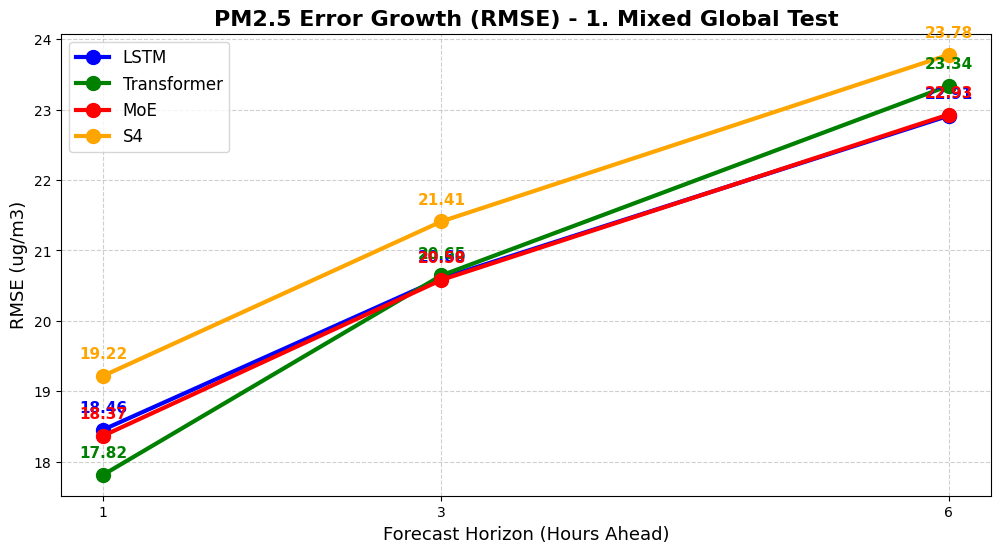

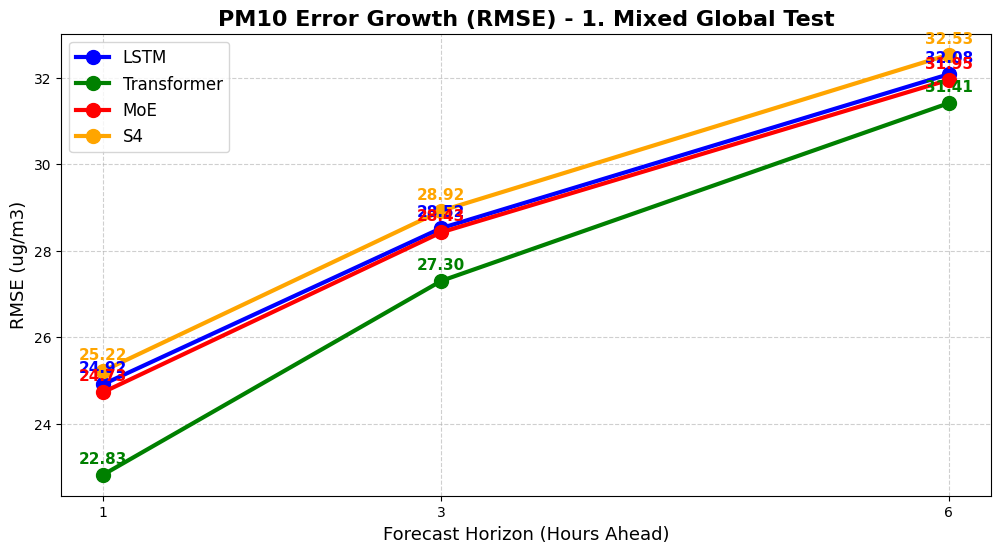

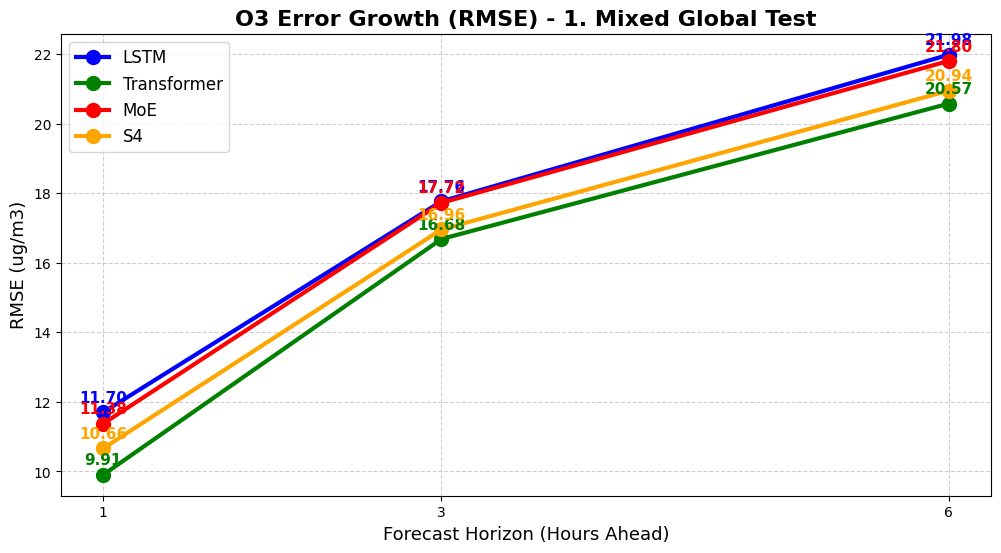

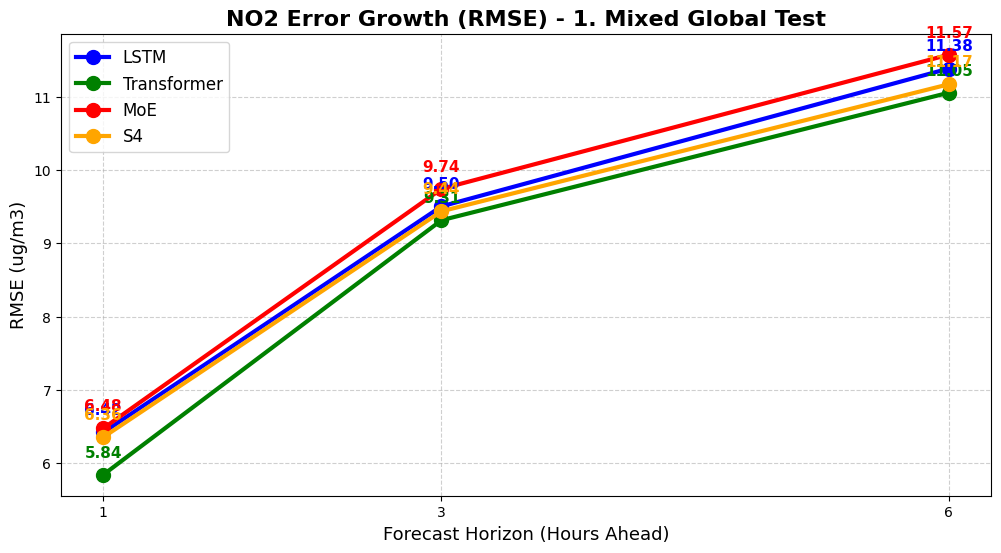

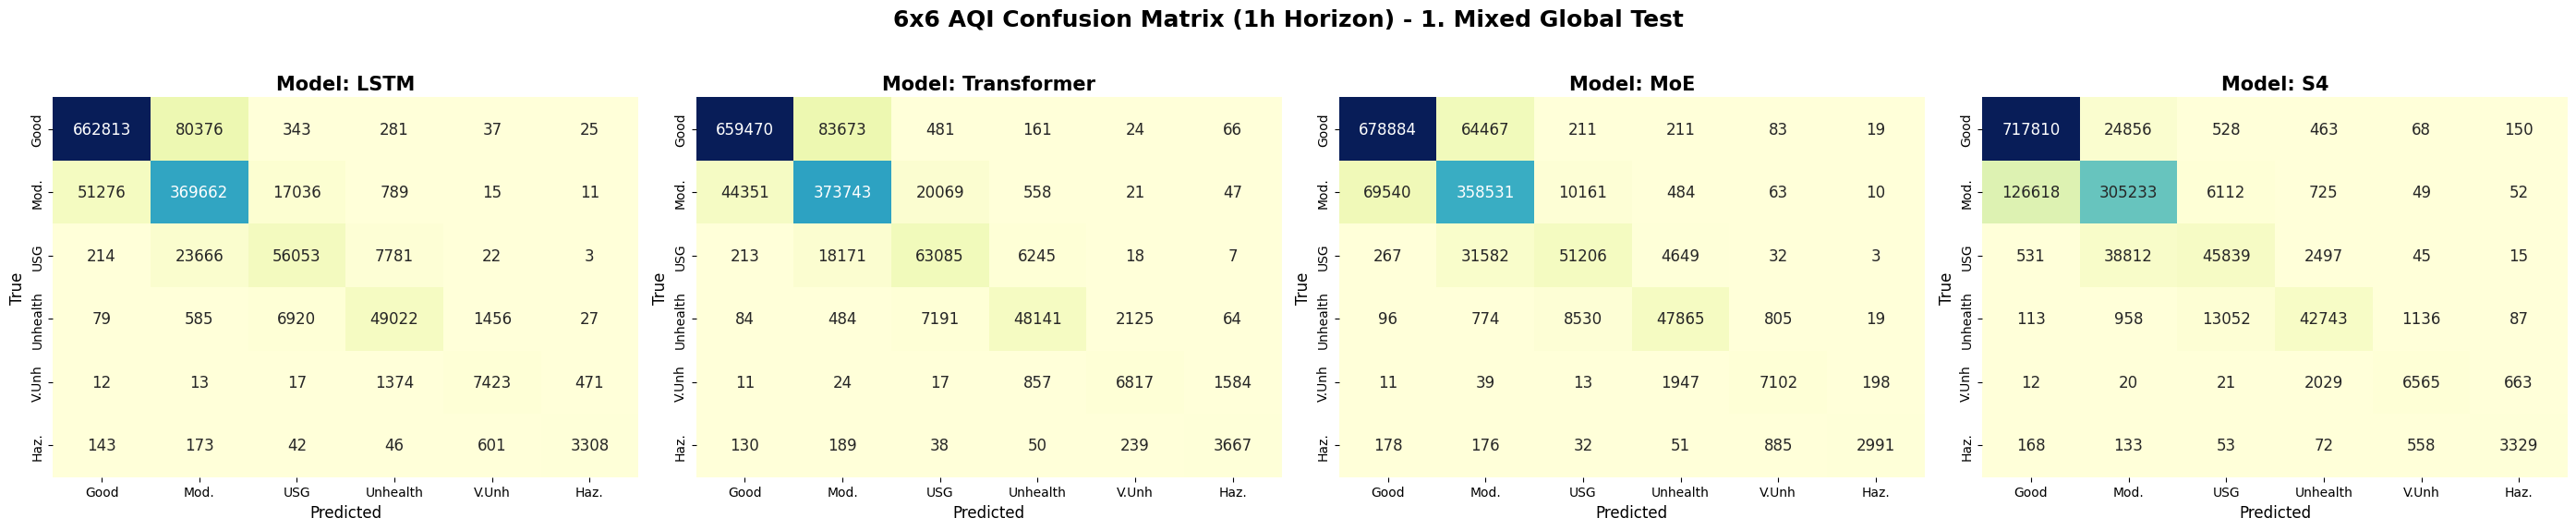


🚀 正在處理場景: 2. Taiwan Local Val


In [ ]:
# ── 終極對決：高解析度視覺化評估 (含點位數值標註) ──
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix

# ==========================================
# 0. 硬體與全域設定
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision('high')
print(f"📊 正在準備高解析度評估系統，設備: {DEVICE}")

# 1. 資料集與模型定義 (比照方案乙規格)
class AirPollutionDataset(Dataset):
    def __init__(self, X, y_reg, y_cls, y_level):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)
        self.y_level = torch.tensor(y_level, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y_reg[idx], self.y_cls[idx], self.y_level[idx]

class LSTM_Baseline(nn.Module):
    def __init__(self, input_dim=25, d_model=128, hidden_dim=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.lstm = nn.LSTM(d_model, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.head_reg = nn.Linear(hidden_dim * 2, 3 * 4); self.head_cls = nn.Linear(hidden_dim * 2, 3 * 1); self.head_lvl = nn.Linear(hidden_dim * 2, 3 * 6) 
    def forward(self, x):
        x = self.embedding(x); out, _ = self.lstm(x); x = out.mean(dim=1)
        return self.head_reg(x).view(-1, 3, 4), self.head_cls(x).view(-1, 3), self.head_lvl(x).view(-1, 3, 6)

class Transformer_Baseline(nn.Module):
    def __init__(self, input_dim=25, d_model=128, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model); self.pos_encoder = nn.Parameter(torch.randn(1, 24, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead=n_heads, dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head_reg = nn.Linear(d_model, 3 * 4); self.head_cls = nn.Linear(d_model, 3 * 1); self.head_lvl = nn.Linear(d_model, 3 * 6) 
    def forward(self, x):
        x = self.embedding(x) + self.pos_encoder; x = self.transformer(x).mean(dim=1)
        return self.head_reg(x).view(-1, 3, 4), self.head_cls(x).view(-1, 3), self.head_lvl(x).view(-1, 3, 6)

class MoELayer(nn.Module):
    def __init__(self, d_model, num_experts, top_k, expansion):
        super().__init__()
        self.experts = nn.ModuleList([nn.Sequential(nn.Linear(d_model, d_model*expansion), nn.GELU(), nn.Linear(d_model*expansion, d_model)) for _ in range(num_experts)])
        self.router = nn.Linear(d_model, num_experts); self.top_k = top_k
    def forward(self, x):
        b, l, d = x.shape; x_f = x.view(-1, d); rw = F.softmax(self.router(x_f), dim=-1); w, i = torch.topk(rw, self.top_k, dim=-1)
        w = w / w.sum(dim=-1, keepdim=True); out = torch.zeros_like(x_f)
        for k in range(self.top_k):
            idx, weight = i[:, k], w[:, k].unsqueeze(-1)
            for e_idx, expert in enumerate(self.experts):
                mask = (idx == e_idx)
                if mask.any(): out[mask] += expert(x_f[mask]) * weight[mask]
        return out.view(b, l, d)

class MultiTaskMoE(nn.Module):
    def __init__(self, input_dim=25, d_model=128, n_heads=4, n_layers=2, num_experts=8, top_k=2, expansion=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model); self.pos_encoder = nn.Parameter(torch.randn(1, 24, d_model))
        self.layers = nn.ModuleList([nn.ModuleDict({'attn': nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True), 'moe': MoELayer(d_model, num_experts, top_k, expansion), 'norm1': nn.LayerNorm(d_model), 'norm2': nn.LayerNorm(d_model)}) for _ in range(n_layers)])
        self.head_reg = nn.Linear(d_model, 3 * 4); self.head_cls = nn.Linear(d_model, 3 * 1); self.head_lvl = nn.Linear(d_model, 3 * 6) 
    def forward(self, x):
        x = self.embedding(x) + self.pos_encoder
        for layer in self.layers:
            attn, _ = layer['attn'](x, x, x); x = layer['norm1'](x + attn); x = layer['norm2'](x + layer['moe'](x))
        x = x.mean(dim=1)
        return self.head_reg(x).view(-1, 3, 4), self.head_cls(x).view(-1, 3), self.head_lvl(x).view(-1, 3, 6)

class S4D_Layer(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.A_real = nn.Parameter(torch.randn(d_model)*0.5); self.A_imag = nn.Parameter(torch.randn(d_model)*0.5); self.C = nn.Parameter(torch.randn(d_model, dtype=torch.complex64))
        self.output_linear = nn.Linear(d_model, d_model); self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        orig_dtype, L = x.dtype, x.shape[1]; x_f32 = x.float(); A = torch.complex(-torch.exp(self.A_real), self.A_imag); t = torch.arange(L, device=x.device).float()
        K = torch.exp(torch.einsum('d, t -> td', A, t)); K = torch.einsum('d, td -> td', self.C, K).real.float() 
        y = torch.fft.irfft(torch.fft.rfft(x_f32, n=2*L, dim=1) * torch.fft.rfft(K, n=2*L, dim=0).unsqueeze(0), n=2*L, dim=1)[:, :L, :]
        return self.dropout(self.output_linear(y.to(orig_dtype)))

class S4_Baseline(nn.Module):
    def __init__(self, input_dim=25, d_model=128, n_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.s4_layers = nn.ModuleList([nn.ModuleDict({'s4': S4D_Layer(d_model, dropout), 'norm': nn.LayerNorm(d_model), 'ffn': nn.Sequential(nn.Linear(d_model, d_model*2), nn.GELU(), nn.Linear(d_model*2, d_model), nn.Dropout(dropout))}) for _ in range(n_layers)])
        self.head_reg = nn.Linear(d_model, 3 * 4); self.head_cls = nn.Linear(d_model, 3 * 1); self.head_lvl = nn.Linear(d_model, 3 * 6) 
    def forward(self, x):
        x = self.embedding(x)
        for layer in self.s4_layers: x = layer['norm'](x + layer['s4'](x)); x = layer['norm'](x + layer['ffn'](x))
        x = x.mean(dim=1)
        return self.head_reg(x).view(-1, 3, 4), self.head_cls(x).view(-1, 3), self.head_lvl(x).view(-1, 3, 6)

# ==========================================
# 2. 準備模型與資料考場
# ==========================================
model_files = {
    "LSTM": "LSTM_best_baseline.pt", "Transformer": "Transformer_best_baseline.pt",
    "MoE": "MoE_best_model.pt", "S4": "S4_best_baseline.pt"
}
loaded_models = {}
for name, f in model_files.items():
    if os.path.exists(f):
        m = (LSTM_Baseline() if name=="LSTM" else Transformer_Baseline() if name=="Transformer" else MultiTaskMoE() if name=="MoE" else S4_Baseline()).to(DEVICE)
        m.load_state_dict(torch.load(f, map_location=DEVICE, weights_only=True)); m.eval(); loaded_models[name] = m
        print(f"  ✅ {name} 載入成功")

venues = {
    "1. Mixed Global Test": DataLoader(AirPollutionDataset(*test_data), batch_size=2048, shuffle=False),
    "2. Taiwan Local Val": DataLoader(AirPollutionDataset(*val_data), batch_size=2048, shuffle=False),
}
if os.path.exists("windows_japan.npz"):
    jp = np.load("windows_japan.npz")
    venues["3. Japan OOD Test"] = DataLoader(AirPollutionDataset(jp['X'], jp['y_reg'], jp['y_cls'], jp['y_level']), batch_size=2048, shuffle=False)

# ==========================================
# 3. 執行推論與「大圖+數值標註」繪圖
# ==========================================
def run_final_duel():
    aqi_labels = ["Good", "Mod.", "USG", "Unhealth", "V.Unh", "Haz."]
    pollutants = ["PM2.5", "PM10", "O3", "NO2"]
    horizons = [1, 3, 6]
    colors = {"LSTM": "blue", "Transformer": "green", "MoE": "red", "S4": "orange"}

    for v_name, loader in venues.items():
        print(f"\n🚀 正在處理場景: {v_name}")
        results = {m: {"rmse": {p: [] for p in pollutants}, "cm": None} for m in loaded_models.keys()}
        
        for m_name, model in loaded_models.items():
            pr, tr, pl, tl = [], [], [], []
            with torch.no_grad():
                for bx, byr, _, byl in loader:
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        orr, _, ol = model(bx.to(DEVICE))
                    pr.append(orr.float().cpu().numpy()); tr.append(byr.numpy())
                    pl.append(torch.argmax(ol, dim=-1).cpu().numpy()); tl.append(byl.numpy())
            pr, tr, pl, tl = np.concatenate(pr), np.concatenate(tr), np.concatenate(pl), np.concatenate(tl)
            
            for h in range(3):
                for p in range(4):
                    mask = ~np.isnan(tr[:, h, p])
                    results[m_name]["rmse"][pollutants[p]].append(math.sqrt(mean_squared_error(tr[:, h, p][mask], pr[:, h, p][mask])))
            results[m_name]["cm"] = confusion_matrix(tl[:, 0].flatten(), pl[:, 0].flatten(), labels=[0,1,2,3,4,5])

        # --- 繪圖 A: 每個污染物一張大圖，含數值標記 ---
        for p in pollutants:
            plt.figure(figsize=(12, 6))
            for m_name in loaded_models.keys():
                y_vals = results[m_name]["rmse"][p]
                plt.plot(horizons, y_vals, label=m_name, color=colors[m_name], marker='o', lw=3, markersize=10)
                # 🟢 加入數值標註
                for x, y in zip(horizons, y_vals):
                    plt.text(x, y + 0.2, f'{y:.2f}', color=colors[m_name], fontweight='bold', ha='center', va='bottom', fontsize=11)
            
            plt.title(f"{p} Error Growth (RMSE) - {v_name}", fontsize=16, fontweight='bold')
            plt.xlabel("Forecast Horizon (Hours Ahead)", fontsize=13)
            plt.ylabel("RMSE (ug/m3)", fontsize=13)
            plt.xticks(horizons); plt.grid(True, ls='--', alpha=0.6); plt.legend(fontsize=12); plt.show()

        # --- 繪圖 B: 混淆矩陣放大版 ---
        fig, axes = plt.subplots(1, len(loaded_models), figsize=(28, 6))
        fig.suptitle(f"6x6 AQI Confusion Matrix (1h Horizon) - {v_name}", fontsize=18, fontweight='bold')
        for i, m_name in enumerate(loaded_models.keys()):
            sns.heatmap(results[m_name]["cm"], annot=True, fmt='d', cmap='YlGnBu', ax=axes[i], cbar=False, xticklabels=aqi_labels, yticklabels=aqi_labels, annot_kws={"size": 12})
            axes[i].set_title(f"Model: {m_name}", fontsize=15, fontweight='bold')
            axes[i].set_xlabel("Predicted", fontsize=12); axes[i].set_ylabel("True", fontsize=12)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

run_final_duel()

In [ ]:
# ── 終極跨域對決：評估「台灣驗證集」與「日本測試集」 ──────────────────────────────
import os
import math
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix

DEVICE = torch.device("cuda")

# 1. 準備 DataLoaders
# A. 台灣驗證集 (從記憶體載入)
loader_tw = DataLoader(AirPollutionDataset(*val_data), batch_size=2048, shuffle=False, num_workers=0)

# B. 日本測試集 (從檔案載入)
jp_file = "windows_japan.npz"
if os.path.exists(jp_file):
    jp_npz = np.load(jp_file)
    loader_jp = DataLoader(
        AirPollutionDataset(jp_npz['X'], jp_npz['y_reg'], jp_npz['y_cls'], jp_npz['y_level']),
        batch_size=2048, shuffle=False, num_workers=0
    )
    print("✅ 日本測試集載入成功")
else:
    loader_jp = None
    print("❌ 找不到日本測試集檔案")

datasets_to_test = {
    "Taiwan Validation (In-Domain Local)": loader_tw,
    "Japan Test (OOD Generalization)": loader_jp
}

# 2. 全面推論與視覺化函數
def evaluate_and_plot(venue_name, dataloader):
    if dataloader is None: return
    
    print(f"\n" + "="*80)
    print(f"🚩 正在進場評估: {venue_name}")
    print("="*80)
    
    horizons = [1, 3, 6]
    pollutants = ["PM2.5", "PM10", "O3", "NO2"]
    model_names = list(loaded_models.keys())
    
    # 儲存該考場的 RMSE 與 混淆矩陣
    venue_rmse = {m: {p: [] for p in pollutants} for m in model_names}
    venue_conf = {}

    for name, model in loaded_models.items():
        all_preds_reg, all_trues_reg = [], []
        all_preds_lvl, all_trues_lvl = [], []
        
        with torch.no_grad():
            for batch_x, batch_y_reg, _, batch_y_lvl in dataloader:
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    out_reg, _, out_lvl = model(batch_x.to(DEVICE))
                all_preds_reg.append(out_reg.float().cpu().numpy())
                all_trues_reg.append(batch_y_reg.numpy())
                all_preds_lvl.append(torch.argmax(out_lvl, dim=-1).cpu().numpy())
                all_trues_lvl.append(batch_y_lvl.numpy())

        preds_reg = np.concatenate(all_preds_reg)
        trues_reg = np.concatenate(all_trues_reg)
        preds_lvl = np.concatenate(all_preds_lvl)
        trues_lvl = np.concatenate(all_trues_lvl)

        # 計算 RMSE 曲線數據
        for h_idx in range(len(horizons)):
            for p_idx, p_name in enumerate(pollutants):
                # 剔除可能存在的少量 NaN
                t = trues_reg[:, h_idx, p_idx].flatten()
                p = preds_reg[:, h_idx, p_idx].flatten()
                mask = ~np.isnan(t)
                rmse = math.sqrt(mean_squared_error(t[mask], p[mask]))
                venue_rmse[name][p_name].append(rmse)
        
        # 儲存 1h 步長的 6x6 混淆矩陣
        venue_conf[name] = confusion_matrix(trues_lvl[:, 0].flatten(), preds_lvl[:, 0].flatten(), labels=[0,1,2,3,4,5])

    # --- 繪圖 A: RMSE 成長曲線 ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"RMSE Error Growth - {venue_name}", fontsize=18, fontweight='bold')
    colors = {"LSTM": "blue", "Transformer": "green", "MoE": "red", "S4": "orange"}
    
    for i, p_name in enumerate(pollutants):
        ax = axes[i//2, i%2]
        for m_name in model_names:
            ax.plot(horizons, venue_rmse[m_name][p_name], label=m_name, 
                    color=colors[m_name], marker='o', lw=2)
        ax.set_title(f"{p_name}", fontsize=14)
        ax.set_xlabel("Horizon (Hours)")
        ax.set_ylabel("RMSE")
        ax.set_xticks(horizons)
        ax.grid(True, ls='--', alpha=0.5)
        ax.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # --- 繪圖 B: 6x6 混淆矩陣 ---
    aqi_labels = ["Good", "Mod.", "USG", "Unhealth", "V.Unh", "Haz."]
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(f"6x6 AQI Confusion Matrix (1h Horizon) - {venue_name}", fontsize=16, fontweight='bold')
    for i, m_name in enumerate(model_names):
        ax = axes[i]
        sns.heatmap(venue_conf[m_name], annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=False,
                    xticklabels=aqi_labels, yticklabels=aqi_labels)
        ax.set_title(f"Model: {m_name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 3. 啟動對決
for name, loader in datasets_to_test.items():
    evaluate_and_plot(name, loader)